# Unified Transactions EDA — SOAIDEATHON-S40

Exploratory analysis of `processed/unified_transactions.csv` (ULB + PaySim + IEEE-CIS,
post-backfill). Covers: schema/nulls, correlation heatmap, distribution graphs,
count graphs, and time-trend line graphs.

Run from the `ml/` directory (same level as `processed/`).

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = os.path.join(os.getcwd(), "processed")
DATA_PATH = os.path.join(PROCESSED_DIR, "unified_transactions.csv")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data

7.2M+ rows — set dtypes up front to keep memory sane, and build a stratified
sample for the plots that don't need the full frame (scatter/line plots on
all rows is unreadable anyway).

In [2]:
dtype_map = {
    "record_id": "string",
    "source": "category",
    "transaction_type": "category",
    "device_type": "category",
    "device_info": "category",
    "device_new": "boolean",
    "payee_new": "boolean",
    "location_change": "boolean",
    "call_active_during_txn": "boolean",
    "label": "int8",
}

df = pd.read_csv(DATA_PATH, dtype=dtype_map, low_memory=False)
print(df.shape)
df.head()

(7237967, 16)


,record_id,source,amount,timestamp,transaction_type,balance_before,balance_after,device_type,device_info,device_new,payee_new,location_change,call_active_during_txn,account_age_days,label,synthetic_fields
0,ulb_0,ulb,149.62,0.0,unknown,NaN,NaN,unknown,generic_desktop,False,False,False,False,4000.0,0,"device_type,device_new,payee_new,location_chan..."
1,ulb_1,ulb,2.69,0.0,unknown,NaN,NaN,unknown,generic_mobile,False,False,False,False,186.0,0,"device_type,device_new,payee_new,location_chan..."
2,ulb_2,ulb,378.66,1.0,unknown,NaN,NaN,unknown,unknown_device,False,False,False,False,4000.0,0,"device_type,device_new,payee_new,location_chan..."
3,ulb_3,ulb,123.50,1.0,unknown,NaN,NaN,unknown,generic_mobile,False,False,False,False,131.0,0,"device_type,device_new,payee_new,location_chan..."
4,ulb_4,ulb,69.99,2.0,unknown,NaN,NaN,unknown,generic_tablet,False,False,False,False,600.0,0,"device_type,device_new,payee_new,location_chan..."


In [3]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 7237967 entries, 0 to 7237966
Data columns (total 16 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   record_id               string  
 1   source                  category
 2   amount                  float64 
 3   timestamp               float64 
 4   transaction_type        category
 5   balance_before          float64 
 6   balance_after           float64 
 7   device_type             category
 8   device_info             category
 9   device_new              boolean 
 10  payee_new               boolean 
 11  location_change         boolean 
 12  call_active_during_txn  boolean 
 13  account_age_days        float64 
 14  label                   int8    
 15  synthetic_fields        str     
dtypes: boolean(4), category(4), float64(5), int8(1), str(1), string(1)
memory usage: 1.9 GB


## 2. Nulls & basic stats

In [4]:
null_report = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
null_report.sort_values("null_pct", ascending=False)

,null_count,null_pct,dtype
balance_after,875347,12.09,float64
balance_before,875347,12.09,float64
record_id,0,0.00,string
source,0,0.00,category
timestamp,0,0.00,float64
amount,0,0.00,float64
transaction_type,0,0.00,category
device_type,0,0.00,category
device_info,0,0.00,category
device_new,0,0.00,boolean


In [5]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
amount,7237967.0,158124.214479,5.691923e+05,0.0,6830.69,46392.32,186287.900,92445516.64
timestamp,7237967.0,605445.840823,2.409919e+06,0.0,163.00,273.00,378.000,15811131.00
balance_before,6362620.0,833883.104074,2.888243e+06,0.0,0.00,14208.00,107315.175,59585040.37
balance_after,6362620.0,855113.668579,2.924049e+06,0.0,0.00,0.00,144258.410,49585040.37
account_age_days,7237967.0,740.559711,8.951332e+02,1.0,177.00,401.00,903.000,4000.00
label,7237967.0,0.004057,6.356910e-02,0.0,0.00,0.00,0.000,1.00


## 3. Stratified sample for heavy plotting

Sample size scales fraud-up: fraud is ~0.4% of the data, so a plain random
sample would barely show any fraud rows on scatter/line plots. Stratified
sample keeps enough of both classes visible.

In [6]:
SAMPLE_SIZE = 200_000

frac_needed = min(1.0, SAMPLE_SIZE / len(df))
# groupby(...).sample() instead of groupby(...).apply(lambda g: g.sample(...)) --
# pandas 3.x drops the grouping column from the group passed into apply() by
# default, which silently loses 'label'. The built-in .sample() on the
# groupby object avoids that entirely.
sample = (
    df.groupby("label", group_keys=False, observed=True)
      .sample(frac=frac_needed, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)
print(sample.shape)
sample["label"].value_counts(normalize=True)

(200000, 16)


label
0    0.995945
1    0.004055
Name: proportion, dtype: float64

## 4. Count graphs — categorical distributions

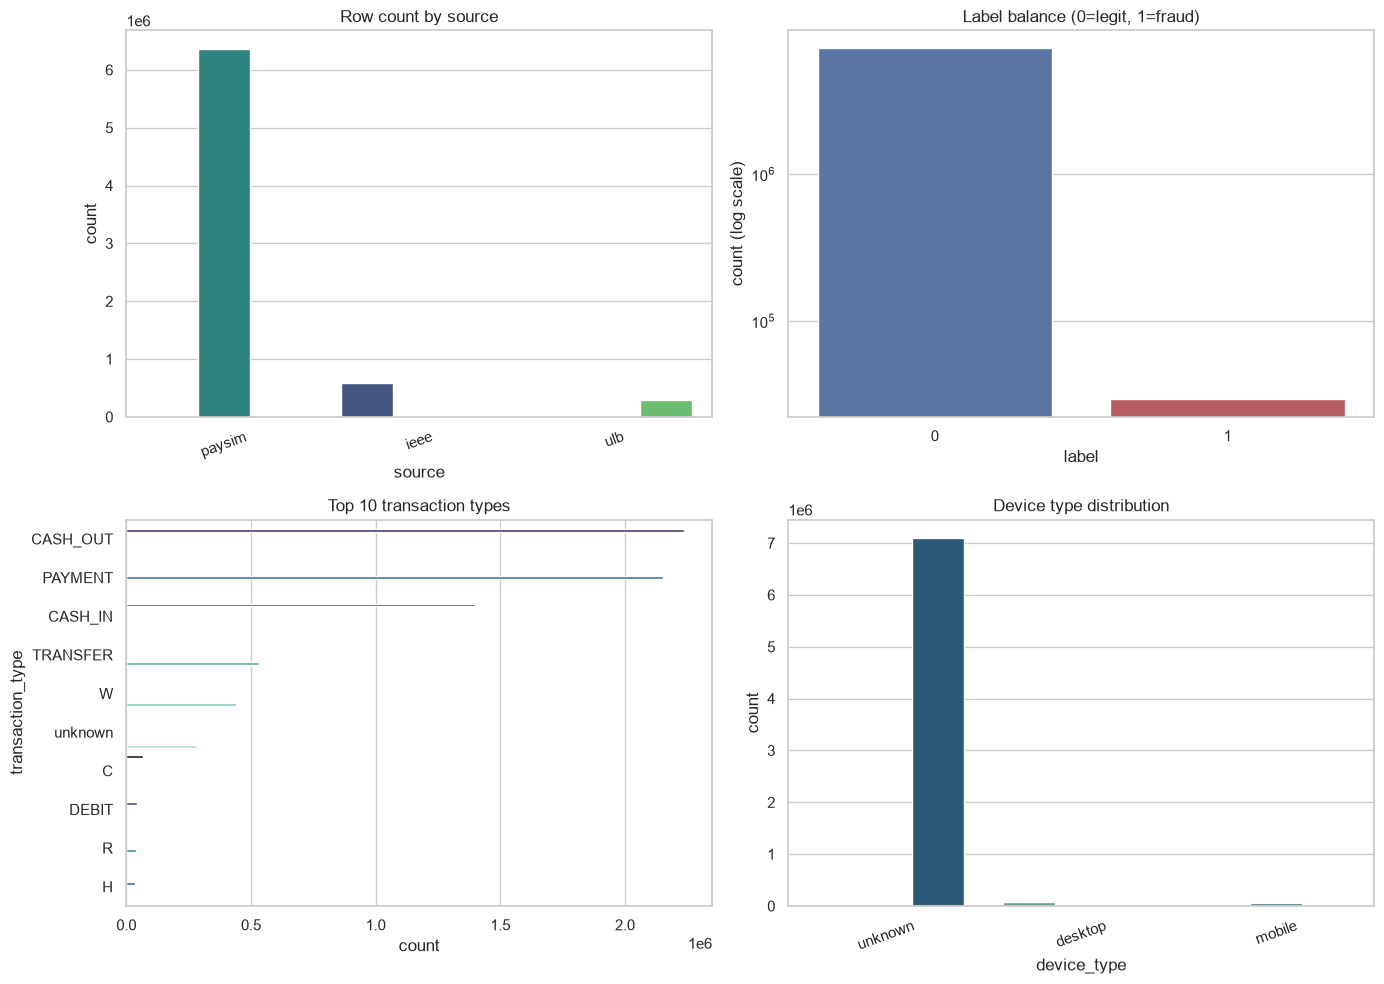

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="source", ax=axes[0, 0], hue="source", legend=False,
              order=df["source"].value_counts().index, palette="viridis")
axes[0, 0].set_title("Row count by source")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="label", ax=axes[0, 1], hue="label", legend=False,
              palette=["#4C72B0", "#C44E52"])
axes[0, 1].set_title("Label balance (0=legit, 1=fraud)")
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("count (log scale)")

top_txn_types = df["transaction_type"].value_counts().head(10).index
sns.countplot(data=df[df["transaction_type"].isin(top_txn_types)], y="transaction_type",
              ax=axes[1, 0], order=top_txn_types, hue="transaction_type", legend=False,
              palette="mako")
axes[1, 0].set_title("Top 10 transaction types")

sns.countplot(data=df, x="device_type", ax=axes[1, 1], hue="device_type", legend=False,
              order=df["device_type"].value_counts().index, palette="crest")
axes[1, 1].set_title("Device type distribution")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

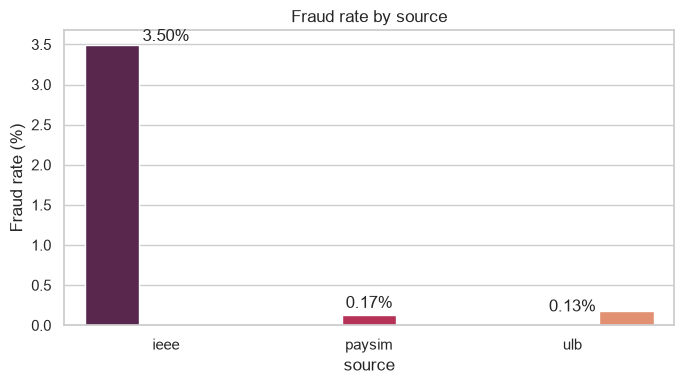

In [8]:
# fraud rate by source -- the metric that actually matters, not raw counts
fraud_rate = df.groupby("source", observed=True)["label"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values, hue=fraud_rate.index, legend=False,
            palette="rocket", ax=ax)
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by source")
for i, v in enumerate(fraud_rate.values):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

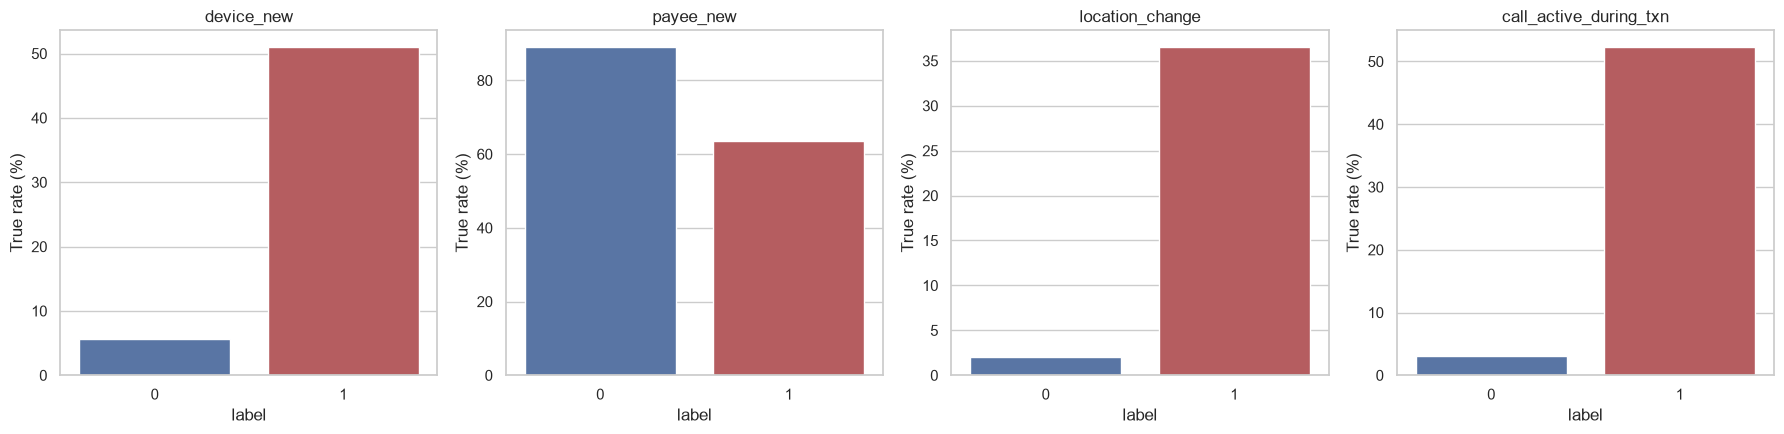

In [9]:
# boolean/synthetic signal count graphs, split by label
bool_cols = ["device_new", "payee_new", "location_change", "call_active_during_txn"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, bool_cols):
    rate = df.groupby("label", observed=True)[col].mean() * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, hue=rate.index.astype(str),
                legend=False, palette=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("label")
    ax.set_ylabel("True rate (%)")
plt.tight_layout()
plt.show()

## 5. Distribution graphs — numeric features

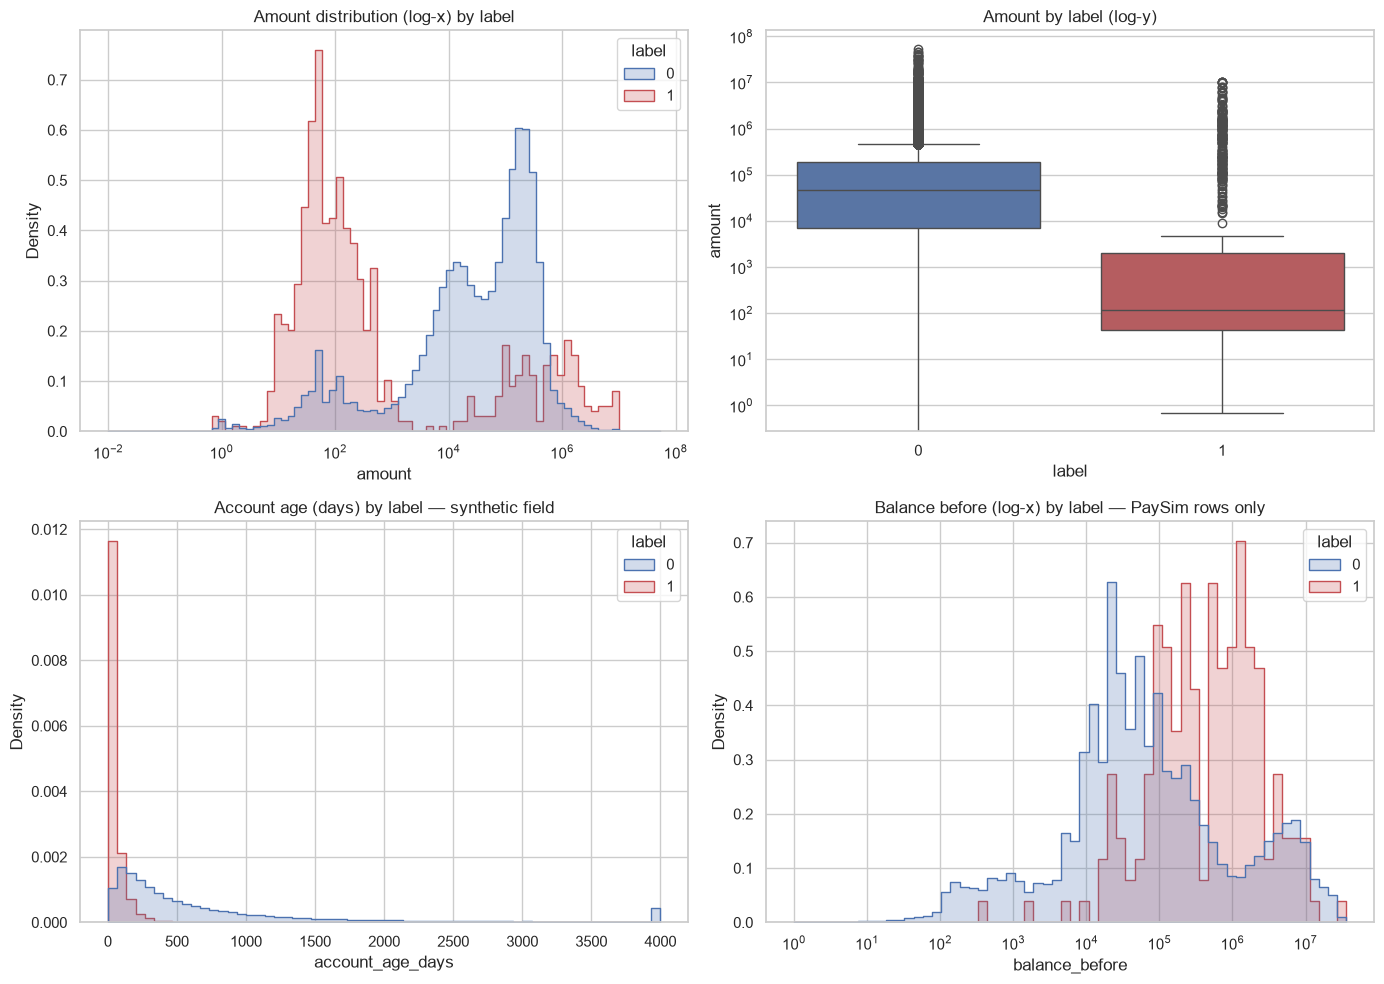

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=sample, x="amount", hue="label", bins=80, log_scale=(True, False),
             ax=axes[0, 0], palette=["#4C72B0", "#C44E52"], element="step", common_norm=False, stat="density")
axes[0, 0].set_title("Amount distribution (log-x) by label")

sns.boxplot(data=sample, x="label", y="amount", hue="label", legend=False,
            ax=axes[0, 1], palette=["#4C72B0", "#C44E52"])
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Amount by label (log-y)")

sns.histplot(data=sample, x="account_age_days", hue="label", bins=60,
             ax=axes[1, 0], palette=["#4C72B0", "#C44E52"], element="step", common_norm=False, stat="density")
axes[1, 0].set_title("Account age (days) by label — synthetic field")

balance_sample = sample[sample["balance_before"].notna()]
sns.histplot(data=balance_sample, x="balance_before", hue="label", bins=60, log_scale=(True, False),
             ax=axes[1, 1], palette=["#4C72B0", "#C44E52"], element="step", common_norm=False, stat="density")
axes[1, 1].set_title("Balance before (log-x) by label — PaySim rows only")

plt.tight_layout()
plt.show()

## 6. Correlation heatmap

Booleans cast to int, categoricals left out (no numeric correlation for
unordered categories — see the count graphs above for those instead).

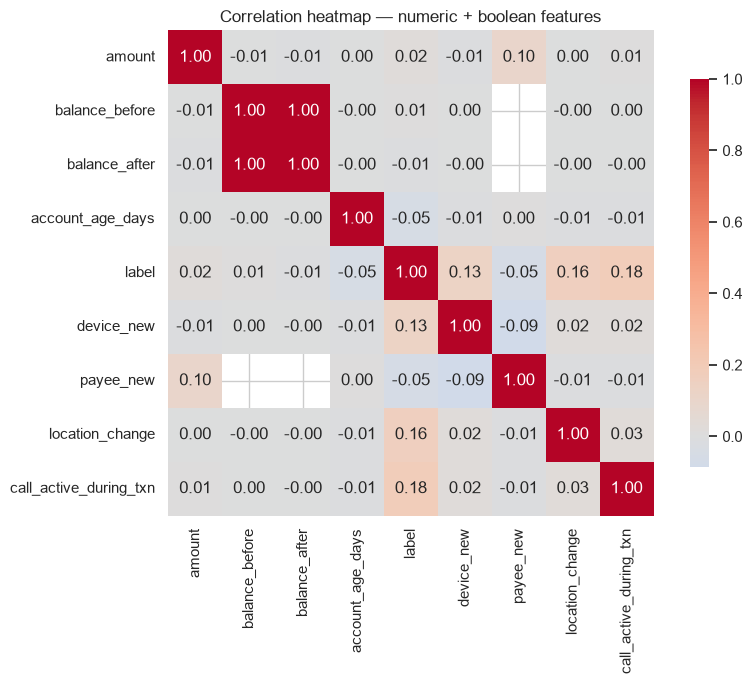

In [11]:
corr_df = sample.copy()
for c in bool_cols:
    corr_df[c] = corr_df[c].astype(float)

numeric_for_corr = ["amount", "balance_before", "balance_after", "account_age_days",
                     "label"] + bool_cols

corr = corr_df[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation heatmap — numeric + boolean features")
plt.tight_layout()
plt.show()

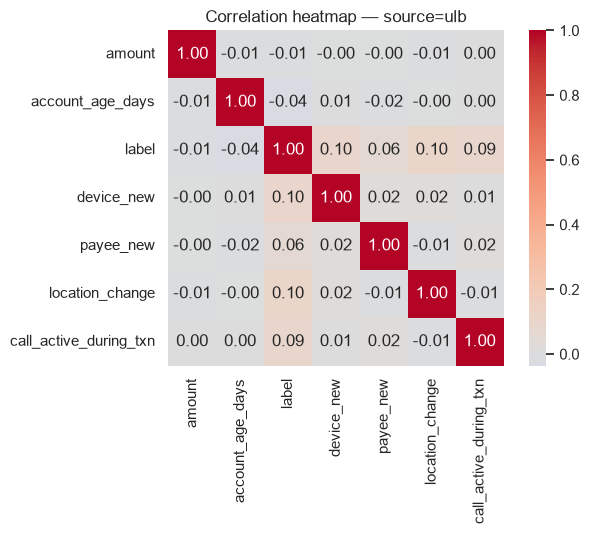

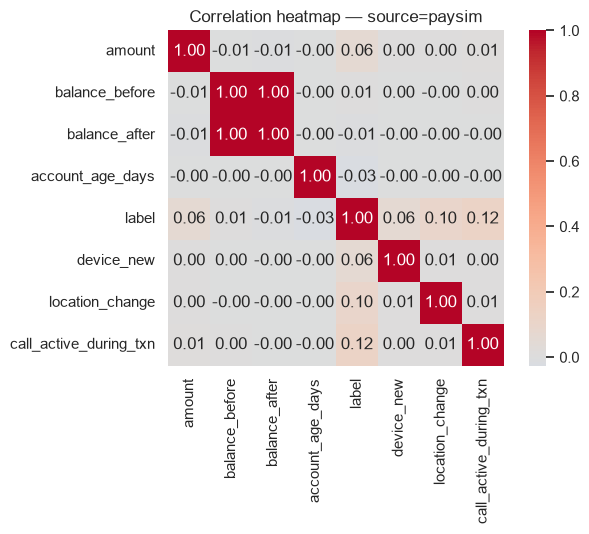

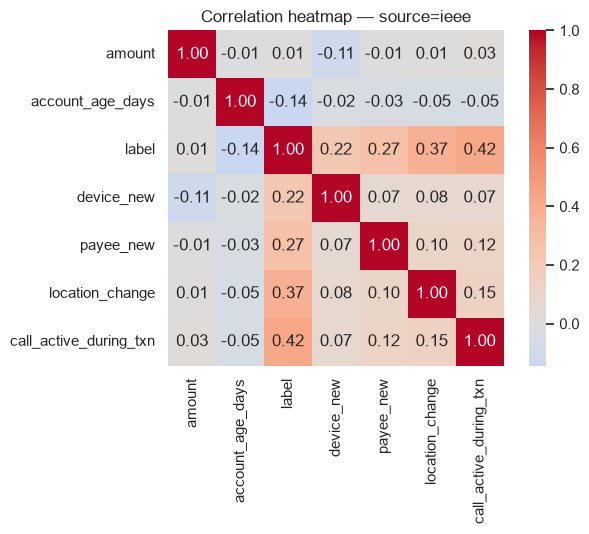

In [12]:
# same thing, split per source -- correlations found on the pooled frame can be
# an artifact of source mixing (e.g. balance_before is all-NaN for ulb/ieee)
for source in df["source"].unique():
    sub = corr_df[corr_df["source"] == source]
    cols_present = [c for c in numeric_for_corr if sub[c].notna().any() and sub[c].std() > 0]
    if len(cols_present) < 2:
        continue
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(sub[cols_present].corr(), annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, square=True)
    ax.set_title(f"Correlation heatmap — source={source}")
    plt.tight_layout()
    plt.show()

## 7. Line graphs — trends

`timestamp` units differ per source (seconds vs hour-steps vs seconds-from-reference),
so trends are plotted **per source**, not pooled, and binned into percentile-based
steps rather than raw time units so the x-axis is comparable across sources.

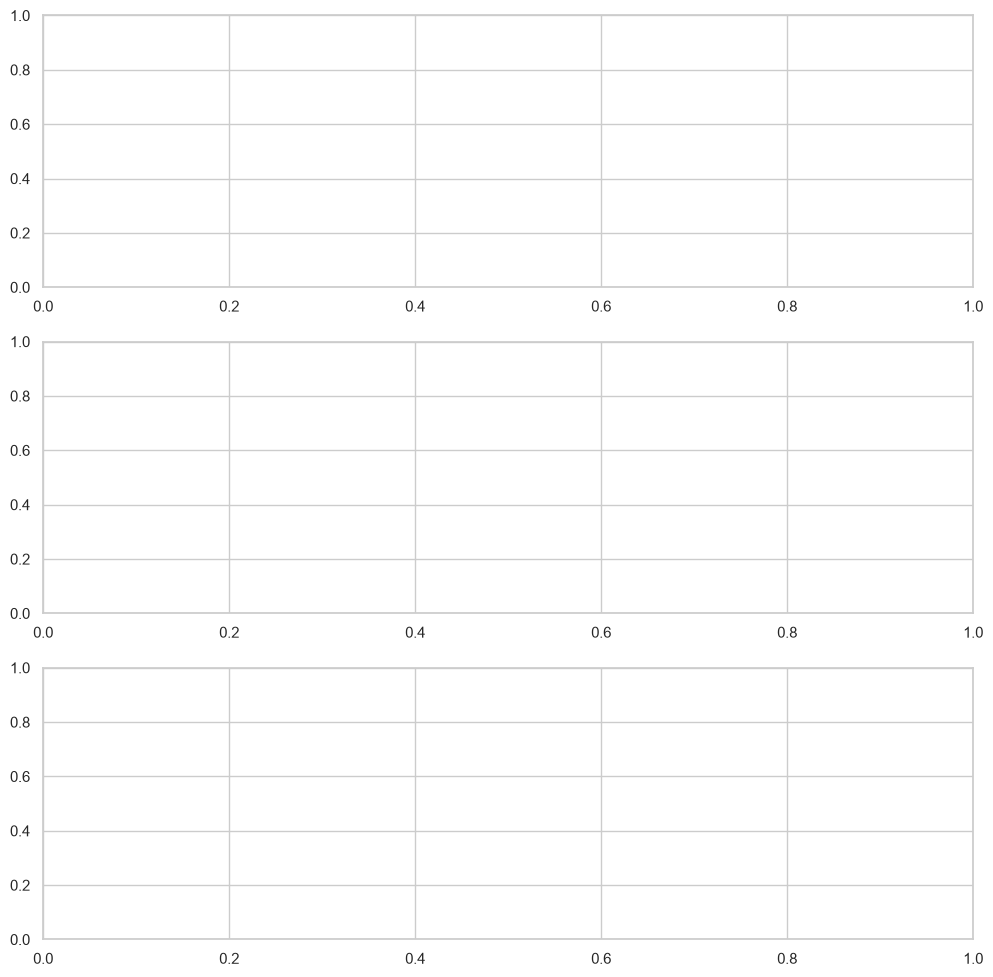

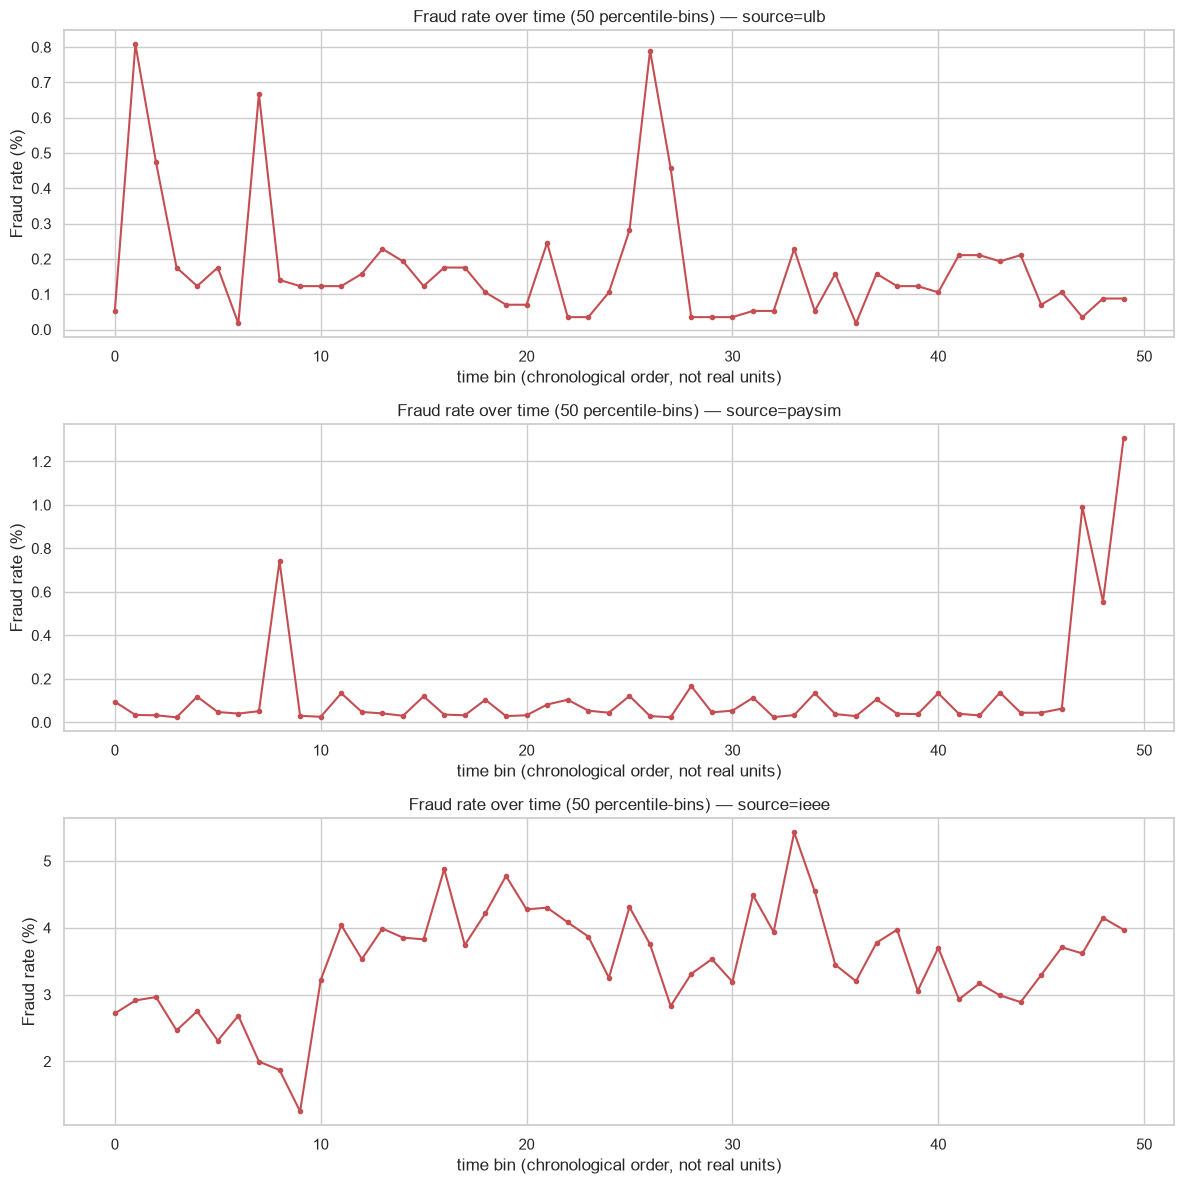

In [13]:
fig, axes = plt.subplots(len(df["source"].cat.categories) if hasattr(df["source"], "cat") else 3,
                          1, figsize=(12, 12), sharex=False)

sources = df["source"].unique()
fig, axes = plt.subplots(len(sources), 1, figsize=(12, 4 * len(sources)))
if len(sources) == 1:
    axes = [axes]

for ax, source in zip(axes, sources):
    sub = df[df["source"] == source].copy()
    sub["time_bin"] = pd.qcut(sub["timestamp"].rank(method="first"), q=50, labels=False)
    trend = sub.groupby("time_bin")["label"].agg(["mean", "count"])
    trend["fraud_rate_pct"] = trend["mean"] * 100

    ax.plot(trend.index, trend["fraud_rate_pct"], marker="o", markersize=3, color="#C44E52")
    ax.set_title(f"Fraud rate over time (50 percentile-bins) — source={source}")
    ax.set_xlabel("time bin (chronological order, not real units)")
    ax.set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

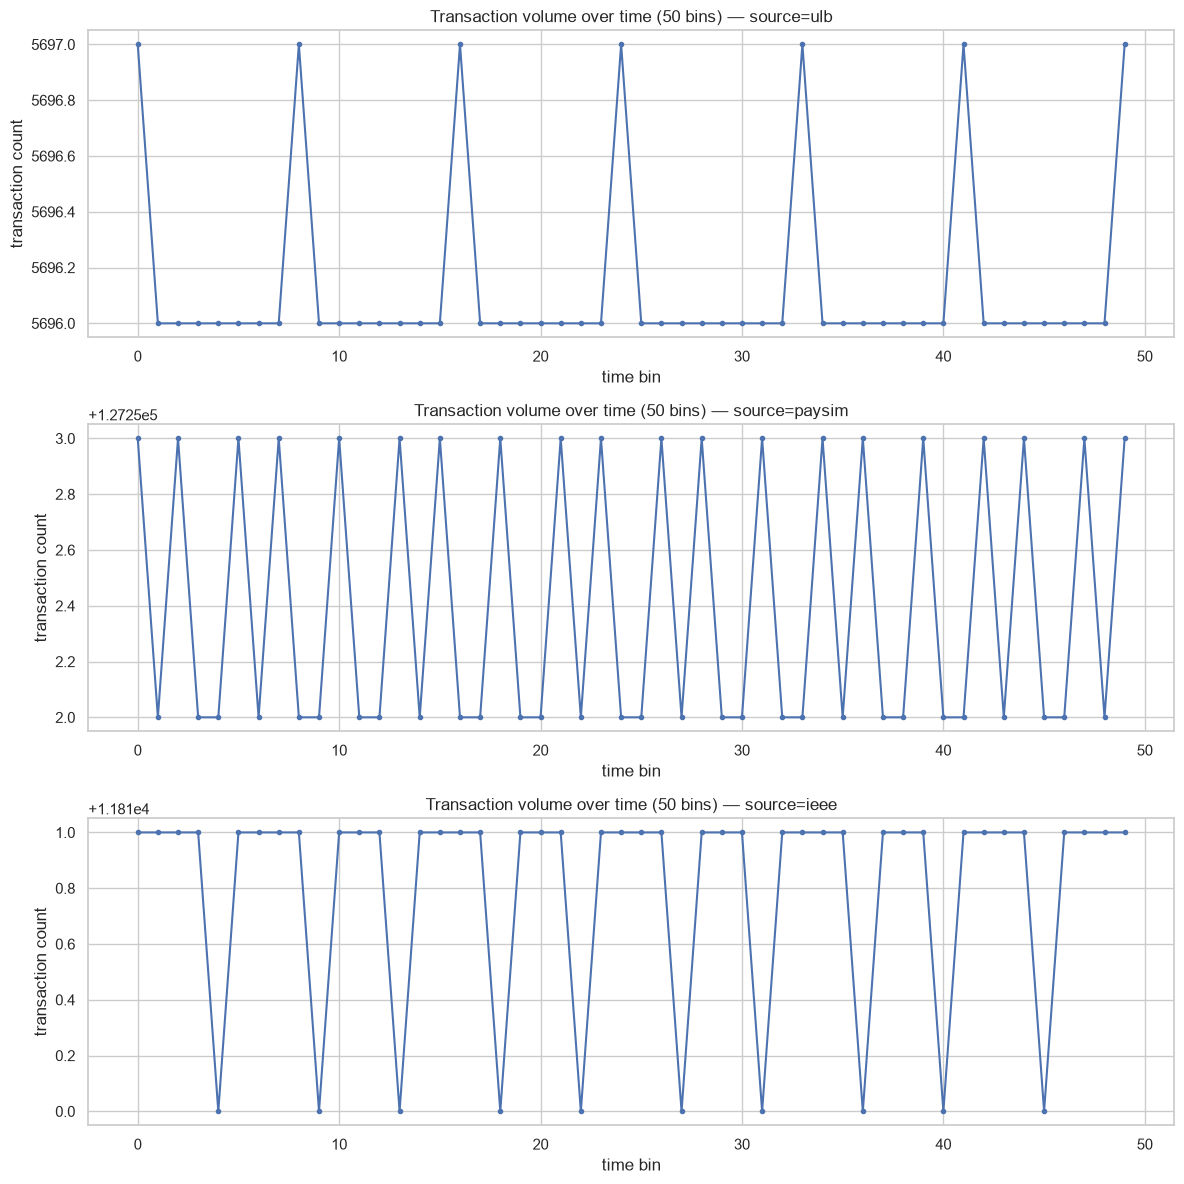

In [14]:
# transaction volume over time per source, same binning approach
fig, axes = plt.subplots(len(sources), 1, figsize=(12, 4 * len(sources)))
if len(sources) == 1:
    axes = [axes]

for ax, source in zip(axes, sources):
    sub = df[df["source"] == source].copy()
    sub["time_bin"] = pd.qcut(sub["timestamp"].rank(method="first"), q=50, labels=False)
    vol = sub.groupby("time_bin").size()

    ax.plot(vol.index, vol.values, marker="o", markersize=3, color="#4C72B0")
    ax.set_title(f"Transaction volume over time (50 bins) — source={source}")
    ax.set_xlabel("time bin")
    ax.set_ylabel("transaction count")

plt.tight_layout()
plt.show()

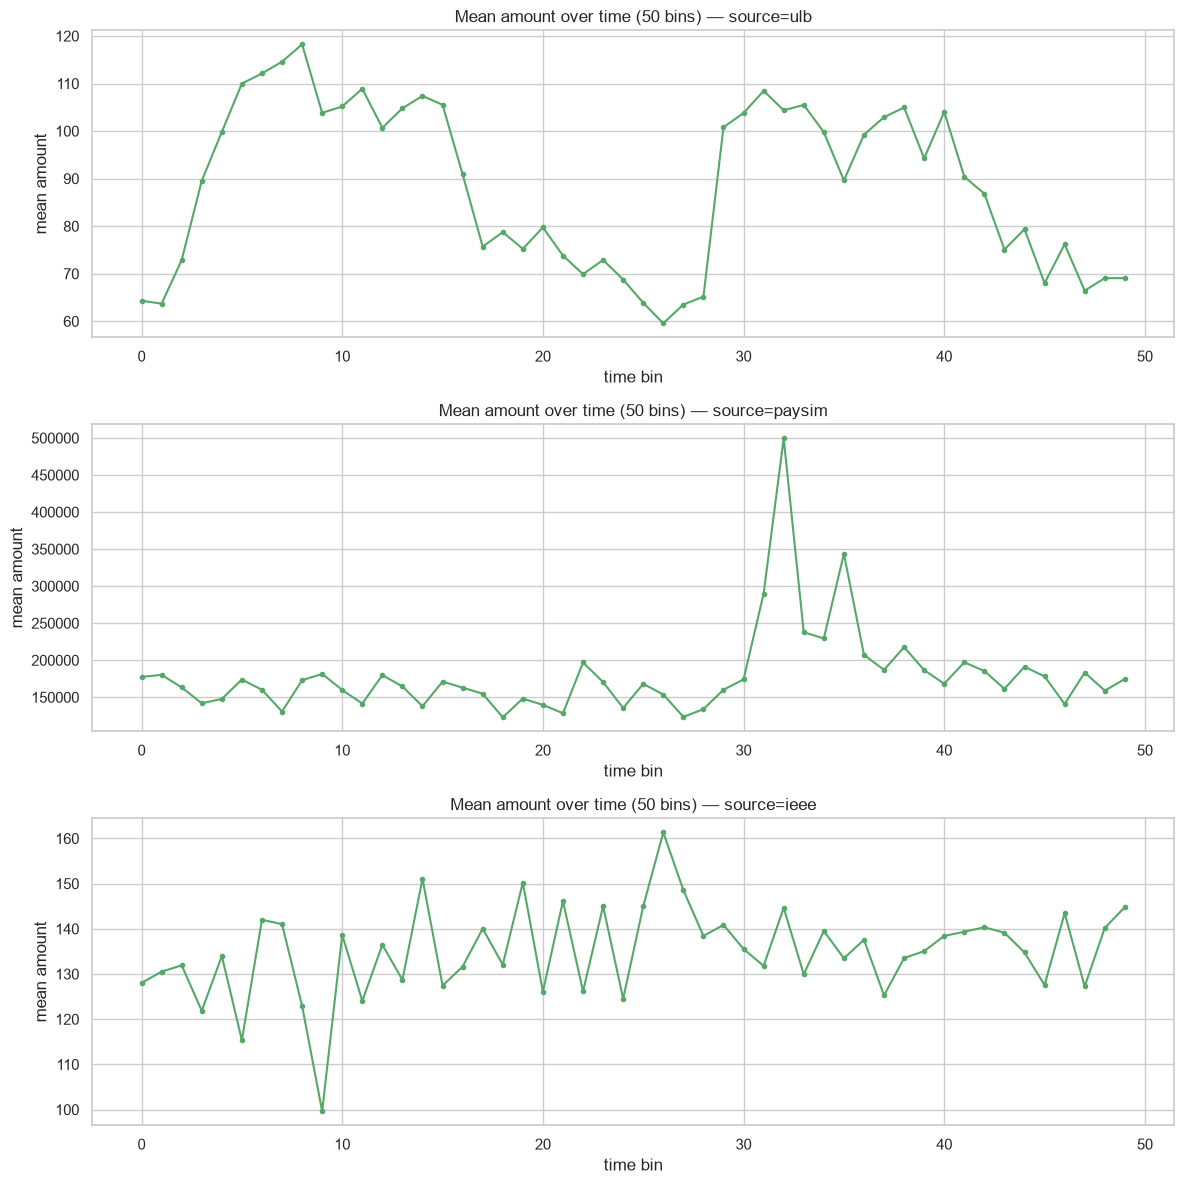

In [15]:
# average amount over time per source -- does typical transaction size drift?
fig, axes = plt.subplots(len(sources), 1, figsize=(12, 4 * len(sources)))
if len(sources) == 1:
    axes = [axes]

for ax, source in zip(axes, sources):
    sub = df[df["source"] == source].copy()
    sub["time_bin"] = pd.qcut(sub["timestamp"].rank(method="first"), q=50, labels=False)
    amt_trend = sub.groupby("time_bin")["amount"].mean()

    ax.plot(amt_trend.index, amt_trend.values, marker="o", markersize=3, color="#55A868")
    ax.set_title(f"Mean amount over time (50 bins) — source={source}")
    ax.set_xlabel("time bin")
    ax.set_ylabel("mean amount")

plt.tight_layout()
plt.show()

## 8. Summary table

Quick reference for the modeling step: fraud rate, row count, and key nulls per source.

In [16]:
summary = df.groupby("source", observed=True).agg(
    rows=("record_id", "count"),
    fraud_rate_pct=("label", lambda s: s.mean() * 100),
    mean_amount=("amount", "mean"),
    median_amount=("amount", "median"),
    has_balance_data_pct=("balance_before", lambda s: s.notna().mean() * 100),
).round(2)
summary

,rows,fraud_rate_pct,mean_amount,median_amount,has_balance_data_pct
source,,,,,
ieee,590540,3.50,135.03,68.77,0.0
paysim,6362620,0.13,179861.90,74871.94,100.0
ulb,284807,0.17,88.35,22.00,0.0
